In [1]:
import os
import sys
from pathlib import Path

# Get the project root directory (parent of notebooks folder)
project_root = str(Path(os.getcwd()).resolve().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Subset
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchsummary import summary

from src.load_data import CatDogDataLoadandSave, split_dataset
from models.vgg16 import VGG16
from models.resnet import ResNetLayer
from src.data_classes import TrainingConfig
from src.train import Trainer

### data path 


In [2]:
data_path = r'/Users/gimoon/Documents/GitHub/Data'

### create dataset 

In [3]:
# CIFAR10 dataset
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load from already downloaded dataset (set download=False)
# CIFAR-10 will be in data_path/cifar-10-batches-py/
dataset_train = datasets.CIFAR10(root=data_path, train=True, download=False, transform=transform)
dataset_test = datasets.CIFAR10(root=data_path, train=False, download=False, transform=transform)

print(f"Training samples: {len(dataset_train)}")
print(f"Test samples: {len(dataset_test)}")


/opt/miniconda3/envs/vgg16_with_py311/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 50000
Test samples: 10000


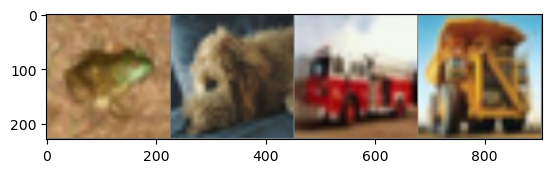

frog  dog   truck truck


In [4]:
import numpy as np
import matplotlib.pyplot as plt

import torchvision
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

trainloader = DataLoader(dataset_train, batch_size=4, shuffle=True)

# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


### Split dataset into training and validation sets, then create DataLoaders

In [5]:
train_dataset, val_dataset = split_dataset(dataset_train, train_ratio=0.8)

# Configuration for training
config = TrainingConfig(
    batch_size=32,
    num_epochs=2,
    num_train_samples=len(train_dataset),  # Set from your dataset
    lr_scheduler_epoch=5,
    save_path=r"/Users/gimoon/Documents/GitHub/vgg16_practice/checkpoints"
)
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training set size: 40000
Validation set size: 10000

Train batches: 1250
Validation batches: 313


### load models

In [ ]:
resnet = ResNetLayer(3,3)
summary(resnet, (3, 224, 224))

In [6]:
#Configure loss function, optimizer, and learning rate scheduler
if torch.backends.mps.is_available():    
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# load model 
model = VGG16(3, 2).to(device)

In [7]:

if device.type == 'cpu':
    summary(model, (3, 224, 224))

### set loss criterion and optimizer 

In [8]:
lr_scheduler_step_size = config.lr_scheduler_step_size()
print(lr_scheduler_step_size)

total_steps = config.total_steps()
print(total_steps)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = StepLR(optimizer, step_size=config.lr_scheduler_step_size, gamma=0.5)

6250
2500


In [9]:
from src.train import Trainer 
trainer = Trainer(model=model,
                config=config, 
                train_loader=train_loader, 
                val_loader=val_loader, 
                criterion=criterion, 
                optimizer=optimizer,
                device=device)

trainer.train()

  0%|          | 0/1250 [00:16<?, ?it/s]



KeyboardInterrupt: 

In [ ]:
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device)
            y = y.to(device=device)
            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train()
    return num_correct/num_samples


In [ ]:
test_loader = DataLoader(CatDogDataLoadandSave(test_data_path))

check_accuracy(val_loader, model)